# Resolutor SAT con PhaseAND/PhaseOR

Este *notebook* implementa una arquitectura cuántica escalable de múltiples registros para resolver problemas de satisfacibilidad booleana (SAT) utilizando el **Algoritmo de Grover**. Este es un enfoque similar al propuesto por (Lin et al., 2023) En lugar de agrupar todo en un único gran registro, el espacio computacional se distribuye a través de $m$ cláusulas en registros independientes. Estos registros actúan como las unidades de información propuestas en el artículo. La codificación de los registros representa la evaluación en el ancilla de una condición de la fórmula a satisfacer. Así, las operaciones **`PhaseAND`** y/o **`PhaseOR`** marcan con fase $π$ los estados que satisfacen la relación lógica completa.

> Lin, S. W., Wang, T. F., Chen, Y. R., Hou, Z., Sanán, D., & Teo, Y. S. (2023). A parallel and distributed quantum SAT solver based on entanglement and quantum teleportation. arXiv preprint arXiv:2308.03344. [https://doi.org/10.48550/arXiv.2308.03344](https://doi.org/10.48550/arXiv.2308.03344)



En definitiva, se ha conseguido crear un resolutor *SAT* aplicando abstracciones lógicas de mayor nivel (**`PhaseAND`**, **`PhaseOR`** y sus negaciones) presentadas en el artículo. Para su implementación se utiliza Qiskit (v2.3), que es un *framework* que normalmente exige programar a muy bajo nivel (puerta a puerta), pero este diseño demuestra el tremendo potencial y el tipo de operaciones complejas que se pueden crear de forma modular estructurando el código con estas abstracciones. Aún así, toda la creación de estas estructuras requieren crearlas de forma incremental desde este menor nivel, por lo que este lenguaje no parece ser del todo apropiado para mayores escalas.

Cada registro cuántico se encarga de codificar la información de una condición específica evaluada por un oráculo, siguiendo una codificación basada en aritmética modular. En este caso práctico, el algoritmo está diseñado para encontrar el estado $x$ que satisfaga la siguiente fórmula en forma normal disyuntiva (DNF):

$$F = [(x > 12) \land (x < 17)] \lor (x = 38) \lor [(x > 39) \land (x < 43)] \lor (x \ge 56) \pmod{64}$$

---
## 1. Instalación de Dependencias
Primero, instalamos los paquetes necesarios de Qiskit y los visualizadores gráficos.

In [1]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.9 MB/s eta 0:00:00


## 2. Importación de Librerías
Importamos las clases fundamentales de Qiskit para la construcción, transpilación y simulación del circuito cuántico, junto con las herramientas gráficas (`matplotlib`, `seaborn`).

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

print("Necessary qiskit and qiskit_aer libraries imported.")

import matplotlib.pyplot as plt
import seaborn as sns

print("Necessary matplotlib and seaborn libraries imported.")

Necessary qiskit and qiskit_aer libraries imported.
Necessary matplotlib and seaborn libraries imported.


##  3. Construcción de Oráculos Condicionales

Los registros de nuestro circuito codifican la información de una condición preestablecida. A continuación, definiremos una serie de "oráculos de probabilidad" que almacenan en un **qubit ancilla** (qubit auxiliar) un valor de verdad indicando si el estado cumple o no una restricción.

Estos oráculos se construyen adpatando las pautas formalizadas por (Sanchez-Rivero et al., 2025) para oráculos de probabilidad en vez de fase. Están construidos únicamente con compuertas `X` y `MCX`.

> Sanchez-Rivero, J., Talaván, D., Garcia-Alonso, J., Ruiz-Cortés, A., & Murillo, J. M. (2025). Automatic generation of efficient oracles: The less-than case. Journal of Systems and Software, 219, 112203. [https://doi.org/10.1016/j.jss.2024.112203](https://doi.org/10.1016/j.jss.2024.112203)



Empezamos definiendo el oráculo para la condición matemática **menor que** (`x < number`):

In [3]:
def oracle_less(number: int, qubits: int):
    """
    Constructs a probability oracle that stores information in an ancilla about
    whether or not a value is less than a certain number. It is hermitian, so
    the adjoint is effectively the same operator.

    Args:
        number (int): The integer value (the specific target state) to be
                      marked.
        qubits (int): The total number of qubits in the oracle register, without
                      considering the ancilla.

    Returns:
        Gate: The Qiskit QuantumCircuit of the probability oracle "less than"
              converted to a Gate object for it to be appended.
    """
    circuit = QuantumCircuit(qubits+1, name=f'Oracle\n x<{number}')

    # Convert the target integer 'number' into its binary representation.
    number_bin = format(number, f'0{qubits}b')
    # Apply gates based on the bits of the target 'number'
    for idx, bit in enumerate(number_bin):
        if bit == '1':
            circuit.x(idx)
            circuit.mcx(list(range(idx+1)), qubits)
            circuit.x(idx)
        elif bit == '0':
            circuit.x(idx)

    for idx, bit in enumerate(number_bin):
        if bit == '0':
            circuit.x(idx)

    return circuit.to_gate()

### Oráculo: Mayor o igual que (`x >= number`)
Reutilizando de forma inteligente el oráculo de "menor que" definido anteriormente, e invirtiendo el valor del qubit ancilla mediante una compuerta `X`, logramos marcar efectivamente los estados que cumplen con la condición inversa.

In [4]:
def oracle_greatereq(number: int, qubits: int):
  """
  Constructs a probability oracle that stores information in an ancilla about
  whether or not a value is greater (or equal) than a certain number. It is
  hermitian, so the adjoint is effectively the same operator.

  Args:
      number (int): The integer value (the specific target state) to be marked.
      qubits (int): The total number of qubits in the oracle register, without
                    considering the ancilla.

  Returns:
      Gate: The Qiskit QuantumCircuit of the probability oracle "greater
            (or equal) than" converted to a Gate object for it to be appended.
  """
  circuit = QuantumCircuit(qubits+1, name=f'Oracle\n x>={number}')

  # Reusing the less-than oracle
  qubit_idx = list(range(qubits + 1))
  circuit.append(oracle_less(number, qubits), qubit_idx)
  # Invert the ancilla value to effectively mark the states
  # for the greater-than instance
  circuit.x(qubits)

  return circuit.to_gate()

### Oráculo: Igual a (`x = number`)
Este oráculo identifica un estado exacto. Convierte el número objetivo a su representación binaria y aplica las compuertas `X` correspondientes a los ceros lógicos para condicionar la activación del qubit ancilla con una precisión absoluta.

In [5]:
def oracle_eq(number: int, qubits: int):
  """
  Constructs a probability oracle that stores information in an ancilla about
  whether or not a value is equal than a certain number. It is hermitian, so the
  adjoint is effectively the same operator.

  Args:
      number (int): The integer value (the specific target state) to be marked.
      qubits (int): The total number of qubits in the oracle register, without
                    considering the ancilla.

  Returns:
      Gate: The Qiskit QuantumCircuit of the probability oracle "equal to"
            converted to a Gate object for it to be appended.
  """
  circuit = QuantumCircuit(qubits+1, name=f'Oracle\n x={number}')

  # Convert the target integer 'number' into its binary representation.
  number_bin = format(number, f'0{qubits}b')

  # Apply gates based on the bits of the target 'number'
  for idx, bit in enumerate(number_bin):
    if bit == '0':
      circuit.x(idx)

  circuit.mcx(list(range(qubits)), qubits)

  for idx, bit in enumerate(number_bin):
    if bit == '0':
      circuit.x(idx)

  return circuit.to_gate()

### Oráculo: Rango o Intervalo (`x ∈ [lower, higher)`)
Combinando espacialmente los oráculos de "menor que" y "mayor o igual que", este oráculo evalúa si el valor se encuentra estrictamente dentro de un intervalo cerrado por el límite inferior y abierto por el límite superior.

In [6]:
def oracle_interval(lower_number: int, higher_number: int, qubits: int):
  """
  Constructs a probability oracle that stores information in an ancilla about
  whether or not a value is inside the range [lower_number, higher_number).
  It is hermitian, so the adjoint is effectively the same operator.

  Args:
      lower_number (int): The lower integer value included in the interval.
      higher_number (int): The higher boundary of the interval.
      qubits (int): The total number of qubits in the oracle register, without
                    considering the ancilla.

  Returns:
      Gate: The Qiskit QuantumCircuit of the probability oracle "greater
            (or equal) than lower_number and less than higher_number"
            converted to a Gate object for it to be appended.
  """
  circuit = QuantumCircuit(qubits+1,
                           name=f'Oracle\n x∈[{lower_number},{higher_number})')

  # Reusing the less-than oracle and greater (or equal) than oracle
  qubit_idx = list(range(qubits + 1))
  circuit.append(oracle_less(higher_number, qubits), qubit_idx)
  circuit.append(oracle_greatereq(lower_number, qubits), qubit_idx)

  # Invert the ancilla value to effectively mark the states
  # for the interval instance
  circuit.x(qubits)

  return circuit.to_gate()

---
##  4. Abstracciones Lógicas de Alto Nivel (`PhaseAND` y `PhaseNOR`, y sus negaciones)

Esta es la sección clave que demuestra cómo se construyen estas abstracciones de mayor nivel:

* **`PhaseAND`**: Combina cláusulas en forma normal conjuntiva (CNF). Aplica un cambio de fase global de $\pi$ a los estados válidos utilizando un control múltiple Z (`MCZ`) sobre los qubits ancilla de cada registro.
* **`PhaseOR`**: Evalúa una forma normal disyuntiva (DNF).

Al enmarcar el problema para el algoritmo de Grover, el programador debe considerar que la amplificación de amplitud opera siempre sobre el **subespacio minoritario**. Si la compuerta `PhaseOR` marca la mayoría de los estados, los que realmente satisfacen la relación NOR (los no marcados) serán los que resulten amplificados (ya que son equivalentes salvo una fase global).

In [7]:
import numpy as np

def PhaseAND(main_circuit: QuantumCircuit, q_regs: list, qubits: int):
  """
  Performs boolean combination of clauses in conjunctive normal form to apply
  π-phase shift

  Args:
        main_circuit (QuantumCircuit): The Qiskit QuantumCircuit object to which
                                       the PhaseAND is applied.
        qubits (int): The total number of qubits in the each register, with the
                      ancilla.
        q_regs (list): A list of QuantumRegister objects representing the
                       clauses.

    Returns:
        QuantumCircuit: The modified Qiskit QuantumCircuit object after
                        appending the PhaseAND operation.
  """
  circuit = QuantumCircuit(*q_regs, name="PhaseAND")

  controls = [q_regs[j][qubits-1] for j in range(len(q_regs)-1)]
  target = q_regs[len(q_regs)-1][qubits-1]

  # Apply MCZ operation
  circuit.h(target)
  circuit.mcx(controls, target)
  circuit.h(target)

  # COnvert to gate and append to main_circuit
  phase_and_gate = circuit.to_gate()
  gate_qubits = [qubit for reg in q_regs for qubit in reg]
  main_circuit.append(phase_and_gate, gate_qubits)

  return main_circuit

  def PhaseNAND(main_circuit: QuantumCircuit, q_regs: list, qubits: int):
  """
  Performs boolean combination negation of clauses in conjunctive normal form to
  apply π-phase shift

  Args:
        main_circuit (QuantumCircuit): The Qiskit QuantumCircuit object to which
                                       the PhaseNAND is applied.
        qubits (int): The total number of qubits in the each register, with the
                      ancilla.
        q_regs (list): A list of QuantumRegister objects representing the
                       clauses.

    Returns:
        QuantumCircuit: The modified Qiskit QuantumCircuit object after
                        appending the PhaseAND operation.
  """
  circuit = QuantumCircuit(*q_regs, name="PhaseAND")

  controls = [q_regs[j][qubits-1] for j in range(len(q_regs)-1)]
  target = q_regs[len(q_regs)-1][qubits-1]

  # Apply MCZ operation
  circuit.h(target)
  circuit.mcx(controls, target)
  circuit.h(target)
  circuit.rz(2*np.pi, target)

  # COnvert to gate and append to main_circuit
  phase_and_gate = circuit.to_gate()
  gate_qubits = [qubit for reg in q_regs for qubit in reg]
  main_circuit.append(phase_and_gate, gate_qubits)

  return main_circuit

# When using Grover, these abstractions are equivalent to their negations
# as the algorithm functions up to global phase. The programmer needs to
# consider that the amplification will be done on the minority subspace.
# That is, if the PhaseNOR gate is applied but it marks most states, then the
# ones that satisfy the OR relation will be amplified instead.

def PhaseNOR(main_circuit: QuantumCircuit, q_regs: list, qubits: int):
  """
  Performs boolean combination negation of clauses in disjunctive normal form to
  apply π-phase shift.

  Args:
        main_circuit (QuantumCircuit): The Qiskit QuantumCircuit object to which
                                       the PhaseNOR is applied.
        qubits (int): The total number of qubits in the each register, with the
                      ancilla.
        q_regs (list): A list of QuantumRegister objects representing the
                       clauses.

    Returns:
        QuantumCircuit: The modified Qiskit QuantumCircuit object after
                        appending the PhaseNOR operation.
  """
  circuit = QuantumCircuit(*q_regs, name='PhaseNOR')

  controls = [q_regs[j][qubits-1] for j in range(len(q_regs)-1)]
  target = q_regs[len(q_regs)-1][qubits-1]

  # Following that NOR is equivalent to AND in negate inputs:
  # Apply X gates over the controls and target
  for control in controls:
    circuit.x(control)
  circuit.x(target)

  # Apply MCZ operation
  #circuit.h(target)
  #circuit.mcx(controls, target)
  #circuit.h(target)
  PhaseAND(circuit, q_regs, qubits)

  # Undo the X gates
  for control in controls:
    circuit.x(control)
  circuit.x(target)
  circuit.rz(2*np.pi, target)

  phase_nor_gate = circuit.to_gate()
  gate_qubits = [qubit for reg in q_regs for qubit in reg]
  main_circuit.append(phase_nor_gate, gate_qubits)

  return main_circuit

  def PhaseNOR(main_circuit: QuantumCircuit, q_regs: list, qubits: int):
  """
  Performs boolean combination of clauses in disjunctive normal form to apply
  π-phase shift.

  Args:
        main_circuit (QuantumCircuit): The Qiskit QuantumCircuit object to which
                                       the PhaseNOR is applied.
        qubits (int): The total number of qubits in the each register, with the
                      ancilla.
        q_regs (list): A list of QuantumRegister objects representing the
                       clauses.

    Returns:
        QuantumCircuit: The modified Qiskit QuantumCircuit object after
                        appending the PhaseNOR operation.
  """
  circuit = QuantumCircuit(*q_regs, name='PhaseNOR')

  controls = [q_regs[j][qubits-1] for j in range(len(q_regs)-1)]
  target = q_regs[len(q_regs)-1][qubits-1]

  # Following that NOR is equivalent to AND in negate inputs:
  # Apply X gates over the controls and target
  for control in controls:
    circuit.x(control)
  circuit.x(target)

  # Apply MCZ operation
  #circuit.h(target)
  #circuit.mcx(controls, target)
  #circuit.h(target)
  PhaseAND(circuit, q_regs, qubits)

  # Undo the X gates
  for control in controls:
    circuit.x(control)
  circuit.x(target)

  phase_nor_gate = circuit.to_gate()
  gate_qubits = [qubit for reg in q_regs for qubit in reg]
  main_circuit.append(phase_nor_gate, gate_qubits)

  return main_circuit

##  5. Operador de Difusión de Grover (`diffuser`)

El operador de difusión (o difusor) es el encargado de rotar el vector de estado hacia las soluciones marcadas, amplificando sus amplitudes y anulando las de los estados incorrectos.

Dado que empleamos una arquitectura distribuida de **múltiples registros**, un difusor estándar no funcionaría. Nuestro difusor primero debe deshacer el entrelazamiento creado inicialmente (`GHZ_Init^\dagger`), aplicar una reflexión sobre el subespacio asociado a $|0\cdots 0\rangle$, y finalmente volver a generar el entrelazamiento para preservar la estructura en la siguiente iteración.

In [8]:
def diffuser(main_circuit: QuantumCircuit, q_regs: list, qubits: int):
        """
        Applies the Grover diffusion operator to the given quantum circuit.
        This operator amplifies the amplitudes of the marked states and
        reduces the amplitudes of the unmarked states, effectively rotating
        the state vector towards the marked states.

        Args:
            main_circuit (QuantumCircuit): The Qiskit QuantumCircuit object to
                                           which the diffuser is appended.
            q_regs (list): A list of QuantumRegister objects representing the
                           clauses.
            qubits (int): The total number of qubits in the oracle register,
                          without considering the ancilla.

        Returns:
            QuantumCircuit: The main Qiskit QuantumCircuit object with the
                            diffusion operation appended.
        """
        circuit = QuantumCircuit(*q_regs, name='Grover\n Diffuser')

        # Undo the entanglement (GHZ_Init^dagger)
        for i in range(qubits):
        # Apply CNOTs in reverse and then Hadamards
          for j in range(1, len(q_regs)):
              circuit.cx(q_regs[0][i], q_regs[j][i])
          circuit.h(q_regs[0][i])
          # Precondition for controlled operation with the |0...0> state
          circuit.x(q_regs[0][i])

        controls = [q_regs[0][i] for i in range(qubits-1)]
        target = q_regs[0][qubits-1]

        # Apply a multi-controlled Z
        circuit.h(target)
        circuit.mcx(controls, target)
        circuit.h(target)

        # Redo the entanglement (GHZ_init)
        for i in range(qubits):
          circuit.x(q_regs[0][i])
          circuit.h(q_regs[0][i])
          for j in range(1, len(q_regs)):
              circuit.cx(q_regs[0][i], q_regs[j][i])

        # Convert diffuser circuit to gate
        diffuser_gate = circuit.to_gate()
        gate_qubits = [q_regs[j][i] for j in range(len(q_regs))
                       for i in range(qubits+1)]

        # Append the gate to the main circuit
        main_circuit.append(diffuser_gate, gate_qubits)

        return main_circuit


## 6. Iteración de Grover

Esta función engloba todas las piezas anteriores para construir una iteración completa del Algoritmo de Grover resolviendo nuestra fórmula modularmente:

1. **Computación de Oráculos**: Anexamos los oráculos matemáticos para que evalúen las restricciones independientes en cada registro.
2. **Evaluación Lógica**: Aplicamos nuestra abstracción `PhaseNOR` para inyectar la fase negativa a la combinación booleana objetivo. Se utiliza frente a `PhaseOR` simplemente porque requiere menor profundida y actúan de forma equivalente en este caso.
3. **Descomputación**: Aplicamos nuevamente los oráculos. Al ser operadores hermíticos ($U = U^\dagger$), los ancillas retornan de forma determinista a su estado base ($|0\rangle$), limpiando los ancillas.
4. **Difusión**: Por último, ejecutamos el `diffuser` para amplificar la probabilidad del subespacio correcto.

In [9]:
def grover_iteration(main_circuit: QuantumCircuit, q_regs: list, qubits: int):
  """
  Applies a single iteration of Grover's algorithm to the quantum circuit.
  This involves applying probability oracles, a boolean combination, and the
  diffuser.

  This case solves the formula in CNF:
  F = [(x > 12) ∧ (x < 17)] ∨ (x = 38) ∨ [(x > 39) ∧ (x < 43)] ∨ (x > 55)
                                                                 (mod 64)

  Args:
      main_circuit (QuantumCircuit): The Qiskit QuantumCircuit object to which
                                     the Grover iteration is applied.
      q_regs (list): A list of QuantumRegister objects representing the
                     clauses.
      qubits (int): The total number of qubits in each register, including the
                    ancilla qubit.

  Returns:
      QuantumCircuit: The modified Qiskit QuantumCircuit object after one Grover
                      iteration.
  """
  # List of oracles implemented as constraints
  # Beware that this implementation is manual, so the number of oracles and
  # registers must add up
  oracle_1 = oracle_interval(13, 17, qubits-1)
  oracle_2 = oracle_eq(38, qubits-1)
  oracle_3 = oracle_interval(40, 43, qubits-1)
  oracle_4 = oracle_greatereq(56, qubits-1)

  # Composing of the oracles into the circuit
  main_circuit.append(oracle_1, q_regs[0])
  main_circuit.append(oracle_2, q_regs[1])
  main_circuit.append(oracle_3, q_regs[2])
  main_circuit.append(oracle_4, q_regs[3])

  # Boolean combination of clauses
  # When used for Grover, the negations work the same as they are equivalent up
  # to a global phase
  PhaseNOR(main_circuit, q_regs, qubits)

  # Composing of the oracles adjoints into the circuit
  main_circuit.append(oracle_1, q_regs[0])
  main_circuit.append(oracle_2, q_regs[1])
  main_circuit.append(oracle_3, q_regs[2])
  main_circuit.append(oracle_4, q_regs[3])

  # Composing of the diffuser into the circuit
  # Created for only one variable instance, necessary modification otherwise
  diffuser(main_circuit, q_regs, qubits-1)

  return main_circuit

## 7. Inicialización de Estados Entrelazados (`ghz_init`)

Para que los diferentes registros representen las mismas variables y procesen la información en paralelo de manera coherente, no basta con inicializarlos por separado. Debemos crear un estado entrelazado masivo tipo GHZ (Greenberger–Horne–Zeilinger) a lo largo de los qubits correspondientes de todos los registros simultáneamente. Esto garantiza que cualquier estado medido al final del circuito esté perfectamente correlacionado a lo largo de todo el sistema.

In [10]:
def ghz_init(main_circuit: QuantumCircuit, q_regs: list, qubits: int):
  """
  Encapsulates the preparation of a GHZ-like entangled state across the qubits
  of all provided registers.

  Args:
      main_circuit (QuantumCircuit): The Qiskit QuantumCircuit object to which
                                     the GHZ-like state preparation is applied.
      q_regs (list): A list of QuantumRegister objects.
      qubits (int): The total number of qubits in each register, including the
                    ancilla qubit.

  Returns:
      QuantumCircuit: The modified Qiskit QuantumCircuit object after the
                      GHZ-like state preparation.
  """
  circuit = QuantumCircuit(*q_regs, name="GHZ_Init")
  # GHZ-like states between registers
  for i in range(qubits-1):
      # Apply Hadamard to the i-th qubit on first register
      circuit.h(q_regs[0][i])

      # Apply CX from the i-th qubit on first register to the i-th qubit of
      # the rest of the registers
      for j in range(1, len(q_regs)):
          circuit.cx(q_regs[0][i], q_regs[j][i])

  # Convert GHZ_Init to gate
  ghz_init_gate = circuit.to_gate()

  # Apply GHZ_Init to all qubits of the circuit
  gate_qubits = [qubit for reg in q_regs for qubit in reg]
  main_circuit.append(ghz_init_gate, gate_qubits)

  return main_circuit

## 8. Configuración y Ejecución del Circuito

Una vez están implementadas todas las partes del circuito, se prueba sobre un caso concreto:

* Configuraremos **7 qubits por registro** (6 para codificar los datos y 1 como ancilla temporal), lo que nos permite abarcar un espacio de búsqueda del $0$ al $63$ ($2^6→\mod(64)$).
* Utilizaremos **$m = 4$ registros**, uno para cada una de las 4 cláusulas de nuestra fórmula DNF principal.

A continuación, instanciamos los registros, inicializamos siguiendo el entrelazamiento de los estados como combinaciones de GHZ, ejecutamos una iteración de Grover completa y visualizamos el diagrama. Gracias a nuestras abstracciones de alto nivel, un circuito enormemente complejo se convierte en una serie de bloques más limpios, manejables y expresivos.

Quantum registers, classical register, and quantum circuit initialized.


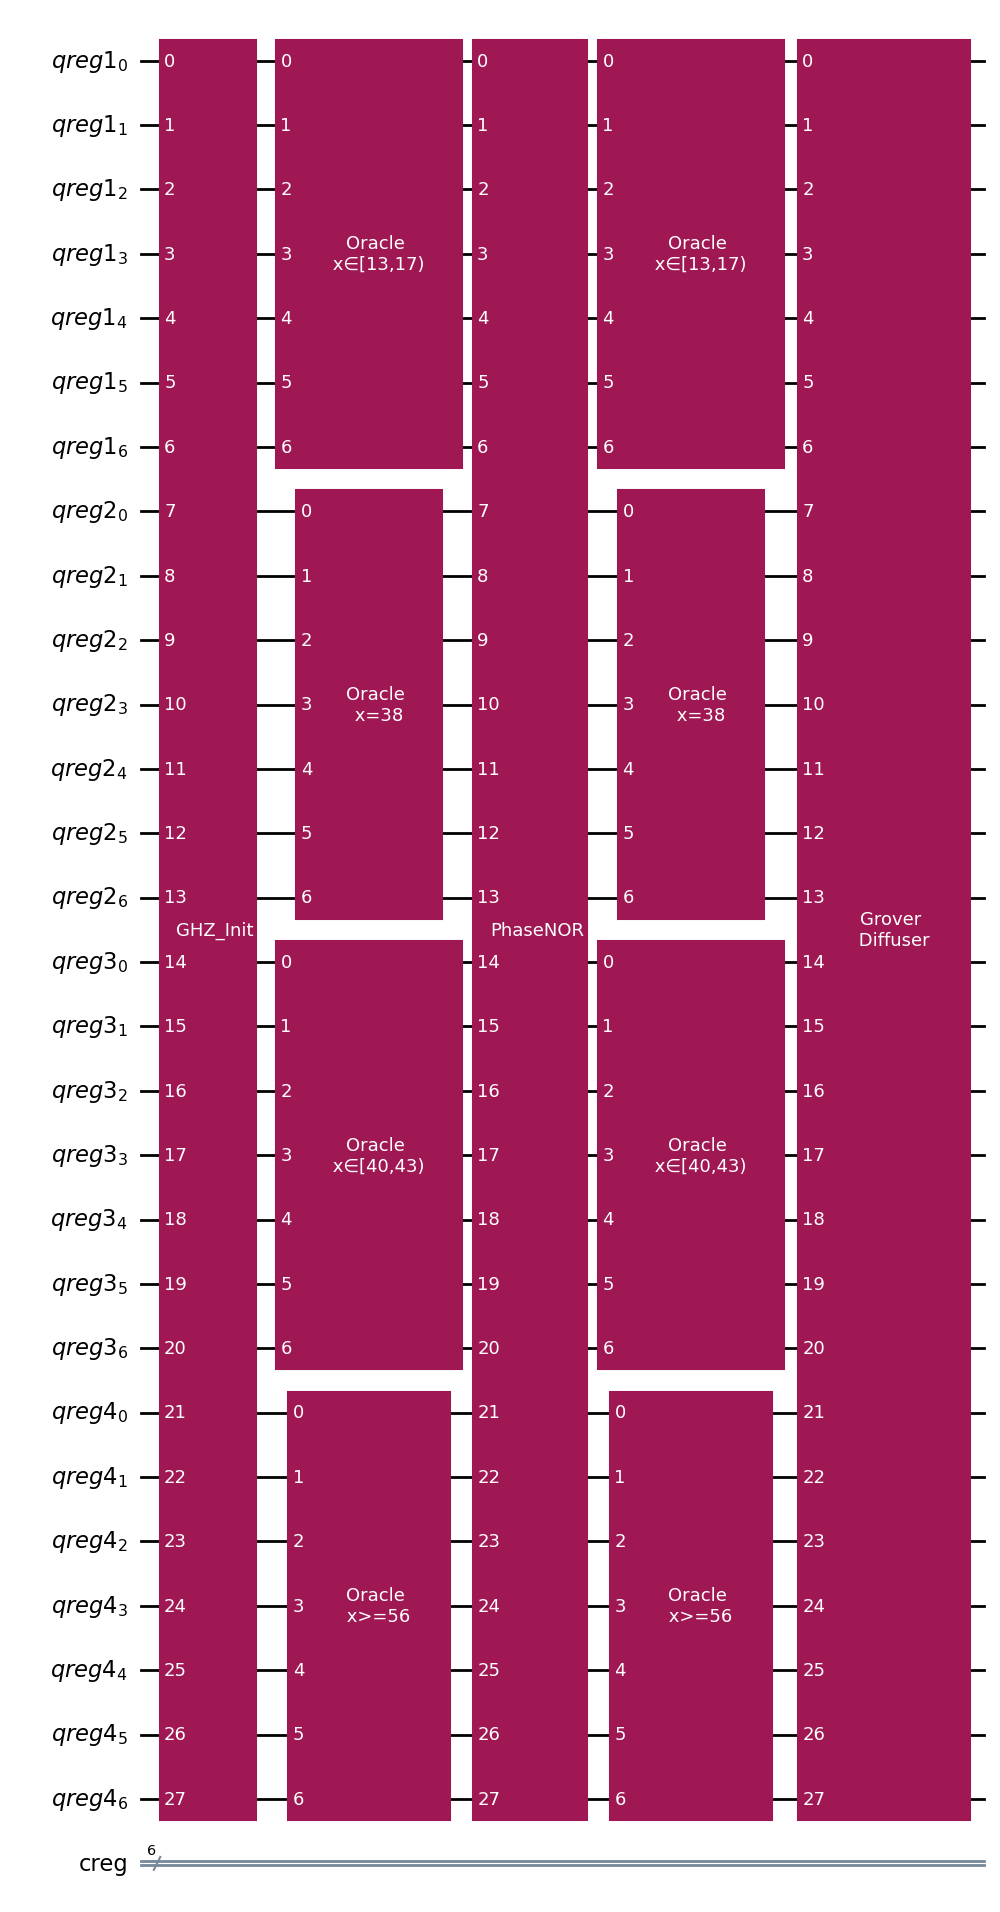

In [11]:
qubits = 7 # Number of qubits in each register, including the ancilla
m = 4 # Number of clauses (number of registers)

q_regs = [QuantumRegister(qubits, f'qreg{j+1}') for j in range(m)]
cr = ClassicalRegister(qubits-1, 'creg')
main_circuit = QuantumCircuit(*q_regs, cr)
print('Quantum registers, classical register, and quantum circuit initialized.')

ghz_init(main_circuit, q_regs, qubits)
grover_iteration(main_circuit, q_regs, qubits)
main_circuit.draw('mpl', fold=-1)

## 9. Medición, Simulación y Análisis de Resultados

In [12]:
def measurement(main_circuit: QuantumCircuit, q_regs: list,
                cr: ClassicalRegister, qubits: int, shots: int):
    """
    Performs the measurement on the primary quantum register, simulates the
    circuit, and plots the measurement outcomes. The keys in the output
    dictionary are inverted to convert from Qiskit's Little-Endian to standard
    Big-Endian notation.

    Args:
        main_circuit (QuantumCircuit): The Qiskit QuantumCircuit object to be
                                       measured.
        q_regs (list): A list of QuantumRegister objects.
        cr (ClassicalRegister): The ClassicalRegister to store the outcomes.
        qubits (int): The total number of qubits in each register, without the
                      ancilla qubit.
        shots (int): The number of times the circuit is to be run.

    Returns:
        None. Prints the outcomes and displays a bar plot.
    """
    # Measure only first regsiter qubits
    for i in range(qubits):
        main_circuit.measure(q_regs[0][i], cr[i])

    # Initialize the simulator and transpile the circuit
    simulator = AerSimulator()
    compiled_circuit = transpile(main_circuit, simulator)

    # Execute the simulation
    job = simulator.run(compiled_circuit, shots=shots)
    result = job.result()
    counts = result.get_counts(compiled_circuit)

    # Invert keys for standard notation (MSB at index 0)
    inverted_counts = {key[::-1]: value for key, value in counts.items()}

    # Sort by decimal value of the bitstring
    sorted_items = sorted(inverted_counts.items(), key=lambda kv: int(kv[0], 2))
    # Format: 010₂ = 2, in ascending decimal order
    formatted_counts = {f'{k}₂ = {int(k, 2)}': v for k, v in sorted_items}
    print(formatted_counts)

    print('Simulation completed. Measurement outcomes with inverted keys to ' +
          'maintain notation:')

    # Histogram for outcome results
    outcome_labels = list(formatted_counts.keys())
    outcome_values = list(formatted_counts.values())

    plt.figure(figsize=(10, 6))
    sns.barplot(x=outcome_labels, y=outcome_values)
    plt.xlabel('Measurement Outcome')
    plt.ylabel('Counts')
    plt.title(f'Quantum Circuit Measurement Outcomes (shots = {shots})')
    plt.xticks(rotation=45, ha='center')
    plt.tight_layout()
    plt.show()

    return None

{'001101₂ = 13': 70, '001110₂ = 14': 58, '001111₂ = 15': 73, '010000₂ = 16': 59, '100110₂ = 38': 61, '101000₂ = 40': 54, '101001₂ = 41': 56, '101010₂ = 42': 59, '111000₂ = 56': 81, '111001₂ = 57': 59, '111010₂ = 58': 79, '111011₂ = 59': 60, '111100₂ = 60': 64, '111101₂ = 61': 64, '111110₂ = 62': 60, '111111₂ = 63': 67}
Simulation completed. Measurement outcomes with inverted keys to maintain notation:


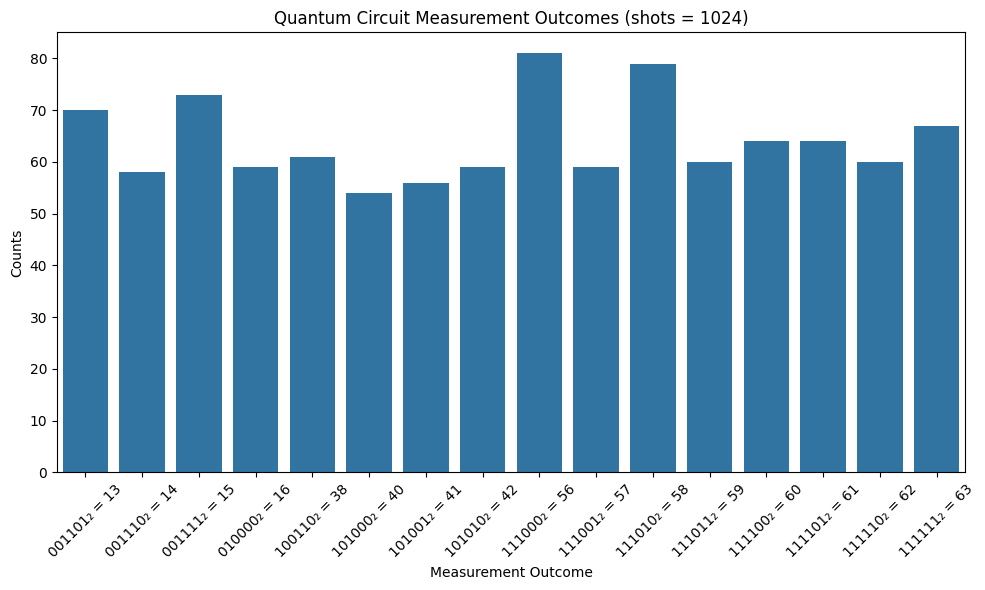

In [13]:
shots=1024
measurement(main_circuit, q_regs, cr, qubits-1, shots)

Como se observa en el histograma, las amplitudes de probabilidad han sido exitosamente amplificadas para los estados $\{13, 14, 15, 16, 38, 40, 41, 42, 56, 57, 58, 59, 60, 61, 62, 63\}$, demostrando que nuestro circuito cuántico modular ha resuelto satisfactoriamente la fórmula planteada.